In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Path setup
RAW_DIR = "../data/raw"
IMG_DIR = os.path.join(RAW_DIR, "ISIC_2019_Training_Input")
CSV_PATH = os.path.join(RAW_DIR, "ISIC_2019_Training_GroundTruth.csv")

In [11]:
df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df.head())

(25331, 10)
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


In [12]:
# Count images per class
class_counts = df.drop(columns='image').sum().sort_values(ascending=False)
print(class_counts)

NV      12875.0
MEL      4522.0
BCC      3323.0
BKL      2624.0
AK        867.0
SCC       628.0
VASC      253.0
DF        239.0
UNK         0.0
dtype: float64


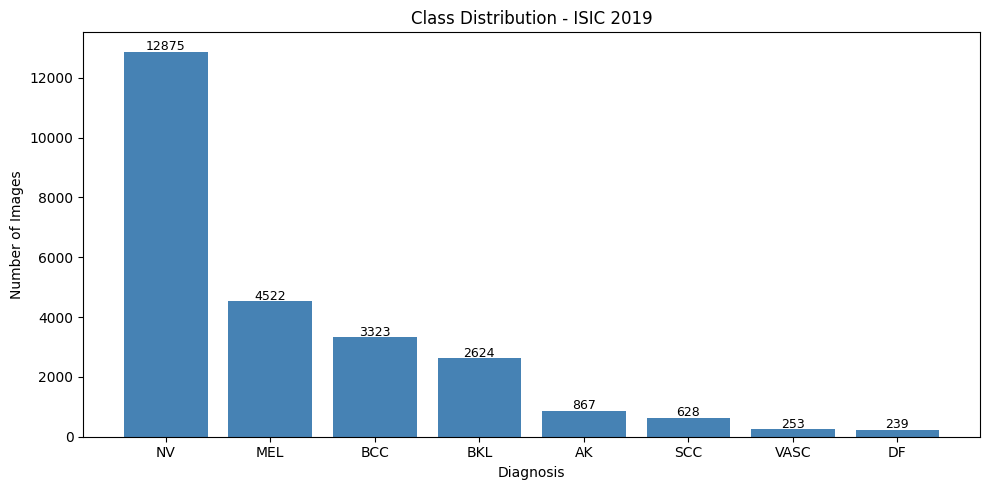

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize=(10, 5))
class_counts_filtered = class_counts[class_counts > 0]
bars = plt.bar(class_counts_filtered.index, class_counts_filtered.values, color='steelblue')
plt.title('Class Distribution - ISIC 2019')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Images')

for bar, val in zip(bars, class_counts_filtered.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(int(val)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')

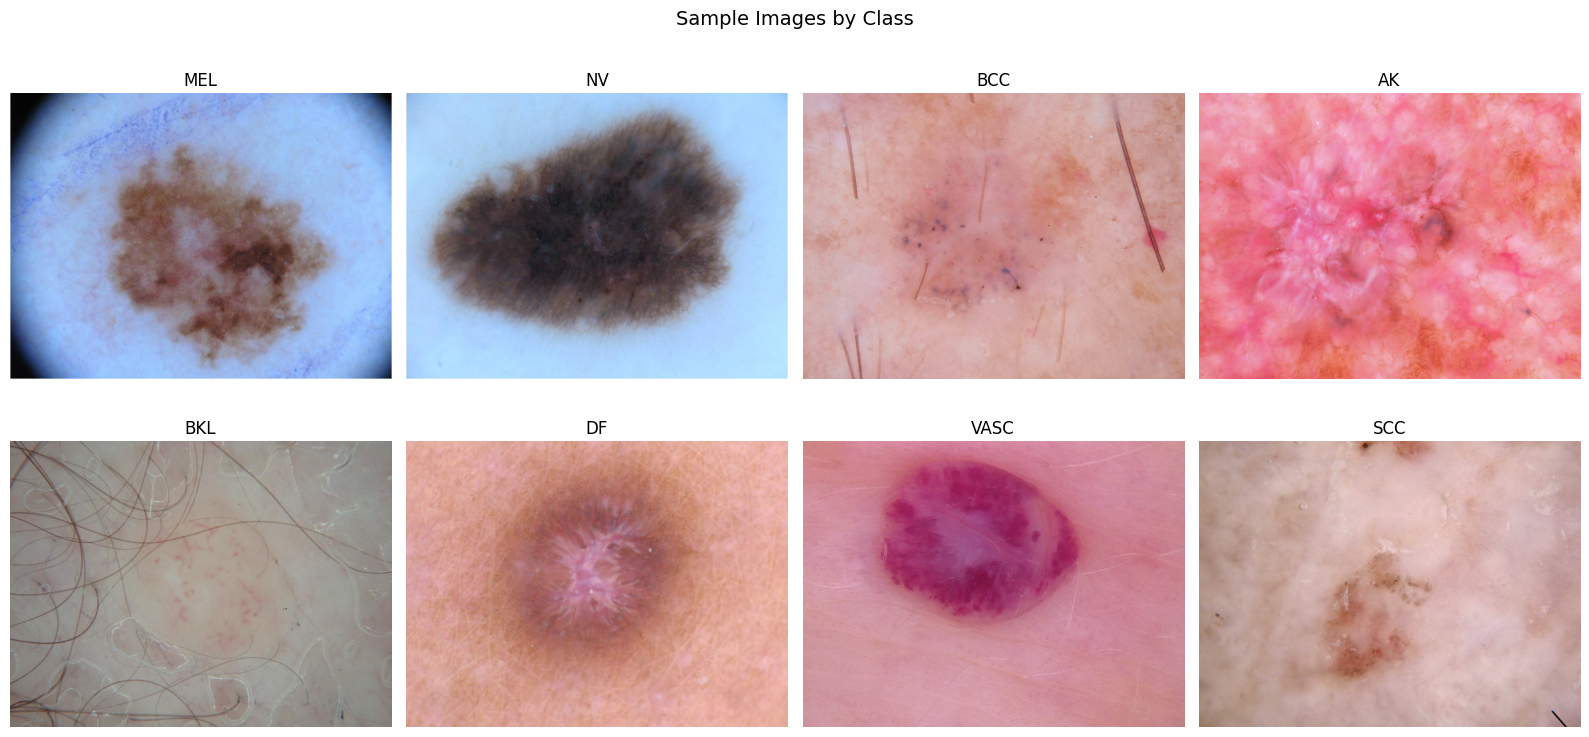

In [16]:
# Display a sample image from each class
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    # Get first image of this class
    img_name = df[df[cls] == 1.0]['image'].iloc[0]
    img_path = os.path.join(IMG_DIR, img_name + '.jpg')
    img = Image.open(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis('off')

plt.suptitle('Sample Images by Class', fontsize=14)
plt.tight_layout()
plt.savefig('../data/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()



In [17]:
# Check image sizes to understand what we're working with
sample_images = df['image'].sample(5).values

for img_name in sample_images:
    img_path = os.path.join(IMG_DIR, img_name + '.jpg')
    img = Image.open(img_path)
    print(f"{img_name}: {img.size} {img.mode}")

ISIC_0053601: (1024, 1024) RGB
ISIC_0029424: (600, 450) RGB
ISIC_0070184: (1024, 1024) RGB
ISIC_0058079: (1024, 1024) RGB
ISIC_0071089: (1024, 1024) RGB
